In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import r2_score


In [2]:
tips = pd.read_csv("tips.csv")

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [4]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


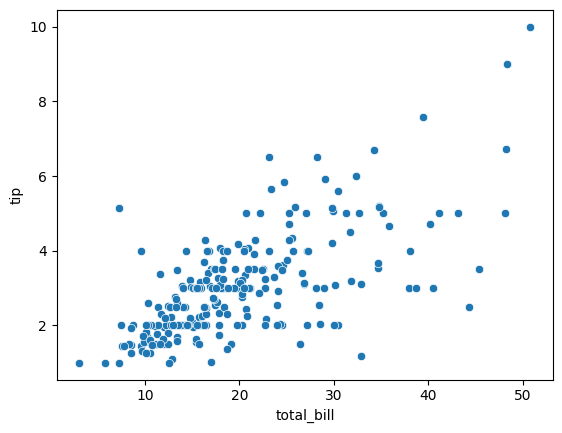

In [5]:
# create a scatterplot of total_bill vs tip amount

sns.scatterplot(x="total_bill", y="tip", data=tips)
plt.show()

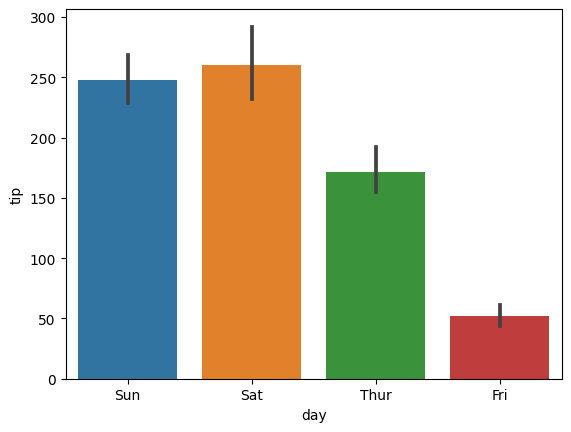

In [6]:
# create a barplot of average tip amount by day of the week
sns.barplot(x="day", y="tip", data=tips, estimator=sum)
plt.show()

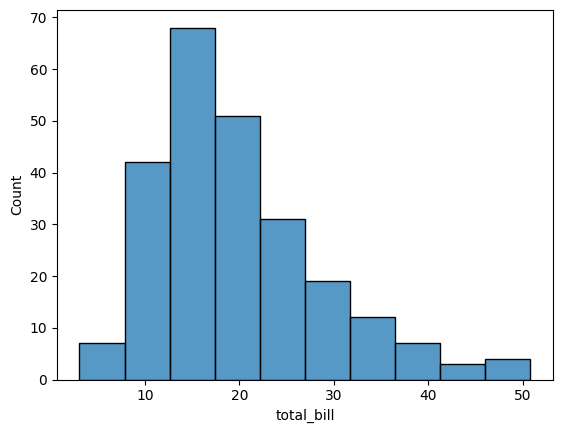

In [7]:
# create a histogram of total bill amount
sns.histplot(x="total_bill", data = tips, bins = 10)
plt.show()

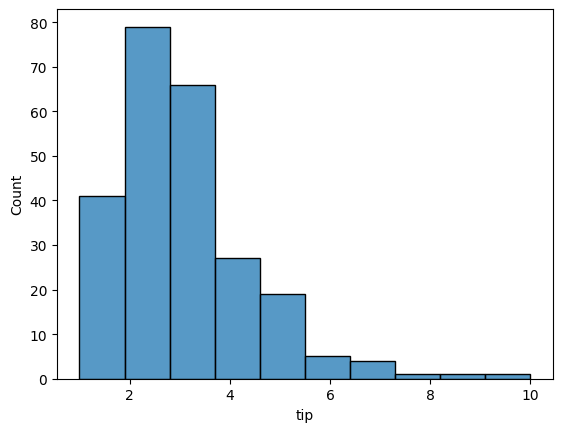

In [8]:
# create a histogram of tips amount
sns.histplot(x="tip", data = tips, bins = 10)
plt.show()

/var/folders/t9/xzq_p4jn637gk3j8dlymkptc0000gn/T/ipykernel_67910/3202808415.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = tips.corr()


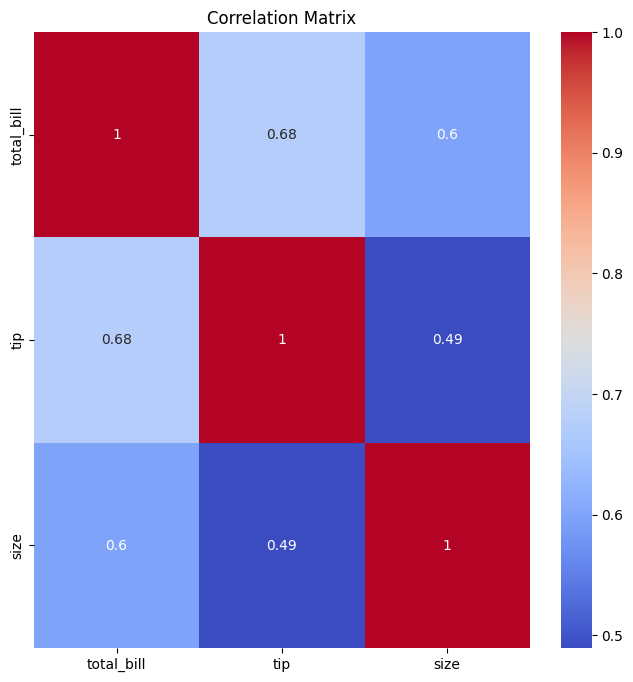

In [9]:
#calculate correlation matrix
corr = tips.corr()

# plot the matrix as a heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

In [10]:
le = LabelEncoder()

tips['sex'] = le.fit_transform(tips['sex'])

tips['smoker'] = le.fit_transform(tips['smoker'])

tips['day'] = le.fit_transform(tips['day'])

tips['time'] = le.fit_transform(tips['time'])

tips.head(20)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4
5,25.29,4.71,1,0,2,0,4
6,8.77,2.00,1,0,2,0,2
7,26.88,3.12,1,0,2,0,4
8,15.04,1.96,1,0,2,0,2
9,14.78,3.23,1,0,2,0,2


In [11]:
X = tips.drop("tip", axis = 1)
y = tips["tip"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

X_train.head()

,total_bill,sex,smoker,day,time,size
7,26.88,1,0,2,0,4
83,32.68,1,1,3,1,2
176,17.89,1,1,2,0,2
106,20.49,1,1,1,0,2
156,48.17,1,0,2,0,6


In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = lr.predict(X_test)

In [14]:
mse = mean_squared_error(y_test, y_pred)
mse

0.8464098890240096

In [15]:
# building a naive prediction model using the mean value of the tip
mean_tip = tips['tip'].mean()

predictions = [mean_tip] * len(y_test)

mse_naive = ((y_test - predictions) ** 2).mean()

mse_naive

2.0093922569914824

In [16]:
rmse = mean_squared_error(y_test, y_pred, squared=False)

rmse

0.9200053744538722

In [17]:
r2 = r2_score(y_test, y_pred)

r2

0.5781801740592984

In [21]:
# Create a linear regression model
X = tips[["total_bill", "size"]]
y = tips["tip"]
lr = LinearRegression().fit(X, y)

# Make predictions and calculate residuals
y_pred = lr.predict(X)
residuals = y - y_pred

#residuals = y_test - y_pred

# Plot residuals against predicted values
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual plot for Homoscedasticity check")
plt.show()

ValueError: operands could not be broadcast together with shapes (49,) (244,) 

In [20]:
from scipy.stats import shapiro

# perform Shapiro-Wilk test on residuals
stat, p = shapiro(residuals)

# interpret the test
alpha = 0.05
print(p)
if p > alpha:
    print('Residuals are normally distributed (fail to reject H0)')
else:
    print('Residuals are not normally distributed (reject H0)')

1.7766886230674572e-05
Residuals are not normally distributed (reject H0)
